In [1]:
import os
from pathlib import Path
from ures.files import filter_files


In [5]:
p_files = filter_files("pt.trace.json", str(Path().home().joinpath("Documents")), fuzz=True)
p_files

['/home/mechrevo/Documents/101-ResearchData/002-xMem-LLM/20250310-163607-a864/results/callback/Profiler/Glaswigian-Researcher_45825.1741624585315484042.pt.trace.json',
 '/home/mechrevo/Documents/101-ResearchData/002-xMem-LLM/20250310-163245-9b59/results/callback/Profiler/Glaswigian-Researcher_43425.1741624386391874170.pt.trace.json',
 '/home/mechrevo/Documents/101-ResearchData/002-xMem-LLM/20250310-163325-87f3/results/callback/Profiler/Glaswigian-Researcher_44127.1741624427354800759.pt.trace.json',
 '/home/mechrevo/Documents/101-ResearchData/002-xMem-LLM/20250310-165111-45b7/results/callback/Profiler/Glaswigian-Researcher_54596.1741625487010937834.pt.trace.json']

In [7]:

from perf_estimator.estimator import TrainerEstimator
from perf_estimator.dataset import image_dataset
file_index = 0
estimator = TrainerEstimator(
    dataloader=image_dataset(batch=100),
    profiler_file=p_files[file_index],
    max_gpu_memory_in_gb=64,
)
model_memory = estimator.model_memory(iteration_index=1, reset=True)

Duplicate layer name found: OPTDecoderLayer_11. Renaming to OPTDecoderLayer_11_96
Duplicate layer name found: LayerNorm_22. Renaming to LayerNorm_22_f6
Duplicate layer name found: OPTSdpaAttention_11. Renaming to OPTSdpaAttention_11_ae
Duplicate layer name found: Linear_66. Renaming to Linear_66_56
Duplicate layer name found: Linear_67. Renaming to Linear_67_67
Duplicate layer name found: Linear_68. Renaming to Linear_68_2d
Duplicate layer name found: Linear_69. Renaming to Linear_69_83
Duplicate layer name found: LayerNorm_23. Renaming to LayerNorm_23_08
Duplicate layer name found: Linear_70. Renaming to Linear_70_55
Duplicate layer name found: ReLU_11. Renaming to ReLU_11_3d
Duplicate layer name found: Linear_71. Renaming to Linear_71_31
Duplicate layer name found: OPTDecoderLayer_10. Renaming to OPTDecoderLayer_10_a2
Duplicate layer name found: LayerNorm_20. Renaming to LayerNorm_20_63
Duplicate layer name found: OPTSdpaAttention_10. Renaming to OPTSdpaAttention_10_03
Duplicate laye

In [8]:
allocator, result = estimator.estimate_memory_blocks(model_memory)

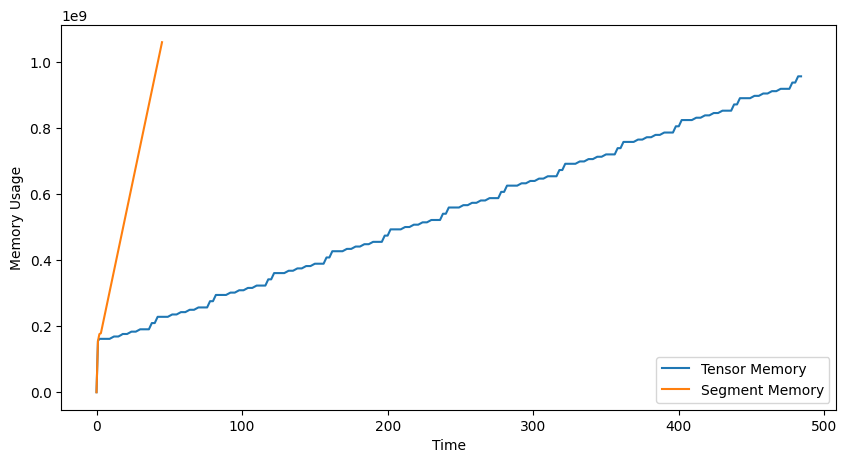

In [9]:
allocator.plot_memory_change()